In [1]:
# All paths in this notebook are relative to the repository root; anchor the working directory there
import os
while not os.path.exists('METHODOLOGY.md') and os.getcwd() != '/': os.chdir('..')
assert os.path.exists('METHODOLOGY.md'), 'run from inside the Nofit_LRT_Extension repository'

# PCA — Car vs Transit Destination Structure in the Survey

The PCA suites so far compared the *survey* with the *cellular* matrix. This notebook applies the same tests **within the survey**, with the mode group as the grouping: do car trips and transit trips share the same destination-choice structure, and where do they diverge? The question matters for the LRT because a transit matrix that is only a scaled-down car matrix would say the LRT market can be read off the car pattern; a transit matrix with its own structure says where transit demand concentrates today, and that is where a new line competes.

**Data.** The 2017 trips file, AM 06:00–09:00, both trip ends in the study area, weighted (`new_wf`), exactly the extraction of step 15. Mode groups: **car** = `mainmode` 10 / 11; **transit** = bus (3, 4) + taxi-type (5, 8) + rail (7); **bus** (3, 4) alone as a sensitivity. Zone conversion by the population / employment split of step 15 (no cellular data). Levels: 36 superzones (primary) and the 28 sub-areas around the corridor; the TAZ level is too sparse for transit (≈ 820 sampled transit trips per day over 778 zones).

**Design.** Origins are observations, row-normalised destination-share profiles are features (as in the earlier suites). Each statistic for *car vs transit* is judged against two references: the **car day 1 vs day 2** and the **transit day 1 vs day 2** repeatability (the same households on two days, so a repeatability reference, not a ceiling), and a **permuted-geography null**. Because transit rows are thin (median ≈ 30 sampled trips per origin superzone over two days), the main comparison pools both days, a **household bootstrap** (200 replicates) gives the sampling range of the overlap, and a restricted run keeps only origins with at least 20 sampled transit trips.

| # | Test | Statistic |
|---|---|---|
| T1 | Dimensionality | scree, n₈₀, participation ratio |
| T2 | Subspace overlap | mean cos² of principal angles, car vs transit; permuted-geography null; household bootstrap |
| T3 | Cross-projection | RCEV(k): transit variance captured by car components and vice versa |
| T4 | Component matching | Tucker congruence, Hungarian-matched; interpretation of the leading components |
| T5 | Divergence map | joint PCA displacement; sign-flip test for a common direction |
| T6 | Divergence anatomy | diagonal share of ‖transit − car‖²; diagonal ablation; the difference matrix by destination |

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy.linalg import subspace_angles
from scipy.optimize import linear_sum_assignment
rng = np.random.default_rng(42)
BLUE, ORANGE, AQUA, PURPLE = '#2a78d6', '#eb6834', '#1baf7a', '#7b5bd6'
INK, INK2, MUTED, GRID, AXIS = '#0b0b0b', '#52514e', '#898781', '#e1e0d9', '#c3c2b7'
CMAP_SEQ = LinearSegmentedColormap.from_list('seq_blue', ['#fcfcfb', '#cde2fb', '#9ec5f4', '#6da7ec', '#3987e5', '#256abf', '#184f95', '#0d366b'])
CMAP_DIV = LinearSegmentedColormap.from_list('div', ['#0d366b', '#2a78d6', '#86b6ef', '#f0efec', '#f2a29e', '#e34948', '#7f1e1e'])
def style_ax(ax, title=None, xlabel=None, ylabel=None):
    ax.grid(True, color=GRID, linewidth=0.6); ax.set_axisbelow(True)
    for s in ax.spines.values(): s.set_color(AXIS)
    ax.tick_params(colors=INK2, labelsize=9)
    if title: ax.set_title(title, color=INK, fontsize=12)
    if xlabel: ax.set_xlabel(xlabel, color=INK2, fontsize=10)
    if ylabel: ax.set_ylabel(ylabel, color=INK2, fontsize=10)
OUT = 'Output/ths2017/tests'; os.makedirs(OUT, exist_ok=True); os.makedirs('Output/figures', exist_ok=True)
def save_show(fig, name): fig.savefig(f'Output/figures/{name}', dpi=150, bbox_inches='tight', facecolor='white'); plt.show()

# ---- trips (step-15 extraction) ----
df = pd.read_excel('Input/trips_ths_2017.xlsx')
d = df.sort_values(['PerID3', 'SurveyDay', 'placeno']).copy(); g = d.groupby(['PerID3', 'SurveyDay'])
d['origin'] = g['actTaz'].shift(1); d['trip_dep_h'] = g['Dep_h'].shift(1)
trips = d.dropna(subset=['origin', 'actTaz', 'trip_dep_h']); trips = trips[trips['trip_dep_h'].isin([6, 7, 8])].copy()
GROUP = {'car': [10, 11], 'transit': [3, 4, 5, 8, 7], 'bus': [3, 4]}
k26 = pd.read_excel('Input/TAZ_2636_Keys.xlsx').drop_duplicates('TAZ_2636'); map_2636_1250 = k26.set_index('TAZ_2636')['TAZ_1250']
trips['o1250'] = trips['origin'].map(map_2636_1250); trips['d1250'] = trips['actTaz'].map(map_2636_1250)
KEYS_LFS = 'Input/Matrices/1270_02_09_2021_TAZ_North_keys.csv'
keys_raw = pd.read_csv('Input/taz_keys_from_shapefile.csv') if open(KEYS_LFS, 'rb').read(40).startswith(b'version https://git-lfs') else pd.read_csv(KEYS_LFS, encoding='windows-1255')
kd = keys_raw[['TAZ_1270', 'TAZ_NUMBER', 'SZ_NEW']].dropna(subset=['TAZ_NUMBER']).astype({'TAZ_NUMBER': int, 'SZ_NEW': int}).drop_duplicates('TAZ_NUMBER')
TAZ = np.array(sorted(kd['TAZ_NUMBER'])); N = len(TAZ); taz_pos = {t: i for i, t in enumerate(TAZ)}
sz_of = kd.set_index('TAZ_NUMBER')['SZ_NEW'].reindex(TAZ).values; SZ = sorted(set(sz_of)); sz_pos = {z: i for i, z in enumerate(SZ)}
children = kd.groupby('TAZ_1270')['TAZ_NUMBER'].apply(list); north_1250 = sorted(children.index); z_idx = {z: i for i, z in enumerate(north_1250)}
tm = trips[trips['o1250'].isin(z_idx) & trips['d1250'].isin(z_idx)].copy(); tm['oi'] = tm['o1250'].map(z_idx); tm['di'] = tm['d1250'].map(z_idx)
zon = pd.read_csv('Input/Zonal_2020.csv', encoding='windows-1255').set_index('TAZ_ID').reindex(TAZ)
pop, emp = zon['POPULATION'].fillna(0).values, zon['EMPL_TOT'].fillna(0).values
def alloc(primary, secondary):
    S = np.zeros((len(north_1250), N))
    for z, kids in children.items():
        idx = [taz_pos[t] for t in kids]
        for v in (primary[idx], secondary[idx], np.ones(len(idx))):
            if v.sum() > 0: S[z_idx[z], idx] = v / v.sum(); break
    return S
S_o, S_d = alloc(pop, emp), alloc(emp, pop)
M_sz = np.zeros((N, len(SZ))); M_sz[np.arange(N), [sz_pos[z] for z in sz_of]] = 1
sub_key = pd.read_excel('Input/Submatrix_tazs.xlsx'); area_of = sub_key.set_index('TAZ')['AggAreaCode']; AREA = sorted(area_of.unique())
M_area = np.zeros((N, len(AREA))); apos = {a: i for i, a in enumerate(AREA)}
for i, t in enumerate(TAZ):
    if t in area_of.index: M_area[i, apos[area_of[t]]] = 1
legend = pd.read_csv('Output/ths2017/study_taz/submatrices/area_legend.csv').set_index('AggAreaCode'); area_names = legend['AggAreaName']
sz_loc = pd.read_csv('Input/sz_localities.csv').set_index('SZ_NEW')['main localities']
Z_SZ, Z_AREA = S_o @ M_sz, S_o @ M_area                     # 1250 -> SZ / area on the origin side
D_SZ, D_AREA = S_d @ M_sz, S_d @ M_area                     # on the destination side

def counts(sub, Zo, Zd, w=None):
    # weighted OD matrix at the aggregate level from a subset of trips
    w = sub['new_wf'].values if w is None else w
    M = np.zeros((len(north_1250),) * 2); np.add.at(M, (sub['oi'].values, sub['di'].values), w)
    return Zo.T @ M @ Zd
def rownorm(M):
    rs = M.sum(axis=1, keepdims=True); return np.divide(M, rs, out=np.zeros_like(M), where=rs > 0)
def n_by_origin(sub, Zo):
    n = np.zeros(len(north_1250)); np.add.at(n, sub['oi'].values, 1); return Zo.T @ n   # sampled-trip equivalents per origin zone

SETS = {}
for grp, codes in GROUP.items():
    sub = tm[tm['mainmode'].isin(codes)]
    for day in (1, 2, 'pooled'):
        s = sub if day == 'pooled' else sub[sub['SurveyDay'] == day]
        SETS[(grp, day)] = {'sz': counts(s, Z_SZ, D_SZ), 'area': counts(s, Z_AREA, D_AREA), 'n_sz': n_by_origin(s, Z_SZ), 'n_area': n_by_origin(s, Z_AREA), 'sampled': len(s)}
print("sampled AM trips (both ends in the study area):", {k: v['sampled'] for k, v in SETS.items() if k[1] == 'pooled'})
print(f"sampled transit trips per origin superzone (2 days): median {np.median(SETS[('transit', 'pooled')]['n_sz']):.0f}, min {SETS[('transit', 'pooled')]['n_sz'].min():.0f}, max {SETS[('transit', 'pooled')]['n_sz'].max():.0f}; origins with >= 20: {(SETS[('transit', 'pooled')]['n_sz'] >= 20).sum()} of {len(SZ)}")

sampled AM trips (both ends in the study area): {('car', 'pooled'): 15949, ('transit', 'pooled'): 1943, ('bus', 'pooled'): 1636}
sampled transit trips per origin superzone (2 days): median 36, min 2, max 192; origins with >= 20: 26 of 36


## 1. Profiles and PCA machinery

In [3]:
def pca(P):
    X = np.asarray(P, float); Xc = X - X.mean(axis=0)
    U, s, Vt = np.linalg.svd(Xc, full_matrices=False); lam = s ** 2 / max(X.shape[0] - 1, 1)
    return {'V': Vt.T, 'lam': lam, 'evr': lam / lam.sum(), 'scores': U * s}
def n_comp(evr, thr): return int(np.searchsorted(np.cumsum(evr), thr) + 1)
def part_ratio(lam): return float(lam.sum() ** 2 / (lam ** 2).sum())
def mean_cos2(Va, Vb, k): return float(np.mean(np.cos(subspace_angles(Va[:, :k], Vb[:, :k])) ** 2))
def rcev(P_target, pc_target, pc_source, k):
    Xc = np.asarray(P_target, float) - np.asarray(P_target, float).mean(axis=0)
    cap = ((Xc @ pc_source['V'][:, :k]) ** 2).sum() / max(Xc.shape[0] - 1, 1); return float(cap / pc_target['lam'][:k].sum())

def level_profiles(level, min_n_transit=1):
    # row-normalised profiles for car / transit / bus (pooled, d1, d2) on the origins that have trips in every set and >= min_n_transit sampled transit trips
    key = 'sz' if level == 'SZ' else 'area'
    ok = np.ones(SETS[('car', 'pooled')][key].shape[0], bool)
    for k_, v in SETS.items(): ok &= v[key].sum(axis=1) > 0
    ok &= SETS[('transit', 'pooled')]['n_' + key] >= min_n_transit
    P = {k_: rownorm(v[key])[ok] for k_, v in SETS.items()}
    return P, ok
P_SZ, ok_sz = level_profiles('SZ'); P_AREA, ok_area = level_profiles('AREA')
PC_SZ = {k_: pca(v) for k_, v in P_SZ.items()}; PC_AREA = {k_: pca(v) for k_, v in P_AREA.items()}
print(f"origins used: SZ {ok_sz.sum()} of {len(SZ)}; areas {ok_area.sum()} of {len(AREA)}")

origins used: SZ 35 of 36; areas 16 of 28


## 2. T1 — Dimensionality

In [4]:
rows = []
for lvl, PC in [('SZ', PC_SZ), ('AREA', PC_AREA)]:
    for key in [('car', 'pooled'), ('transit', 'pooled'), ('bus', 'pooled'), ('car', 1), ('car', 2), ('transit', 1), ('transit', 2)]:
        pc = PC[key]; rows.append({'level': lvl, 'matrix': f'{key[0]} {key[1]}', 'PC1 share': pc['evr'][0], 'n80': n_comp(pc['evr'], .8), 'n90': n_comp(pc['evr'], .9), 'participation ratio': part_ratio(pc['lam'])})
t1 = pd.DataFrame(rows)
kSZ = n_comp(PC_SZ[('car', 'pooled')]['evr'], .8); kAREA = n_comp(PC_AREA[('car', 'pooled')]['evr'], .8)
print(f"headline subspace dimension (80 % of car variance): k = {kSZ} at SZ, k = {kAREA} on the sub-areas")
t1.round(3)

headline subspace dimension (80 % of car variance): k = 20 at SZ, k = 6 on the sub-areas


,level,matrix,PC1 share,n80,n90,participation ratio
0,SZ,car pooled,0.067,20,24,25.325
1,SZ,transit pooled,0.116,14,18,17.021
2,SZ,bus pooled,0.113,14,18,17.674
3,SZ,car 1,0.067,20,24,25.295
4,SZ,car 2,0.067,20,24,25.263
5,SZ,transit 1,0.106,14,18,17.603
6,SZ,transit 2,0.118,13,18,16.489
7,AREA,car pooled,0.201,6,8,7.580
8,AREA,transit pooled,0.219,6,8,7.225
9,AREA,bus pooled,0.227,6,8,7.259


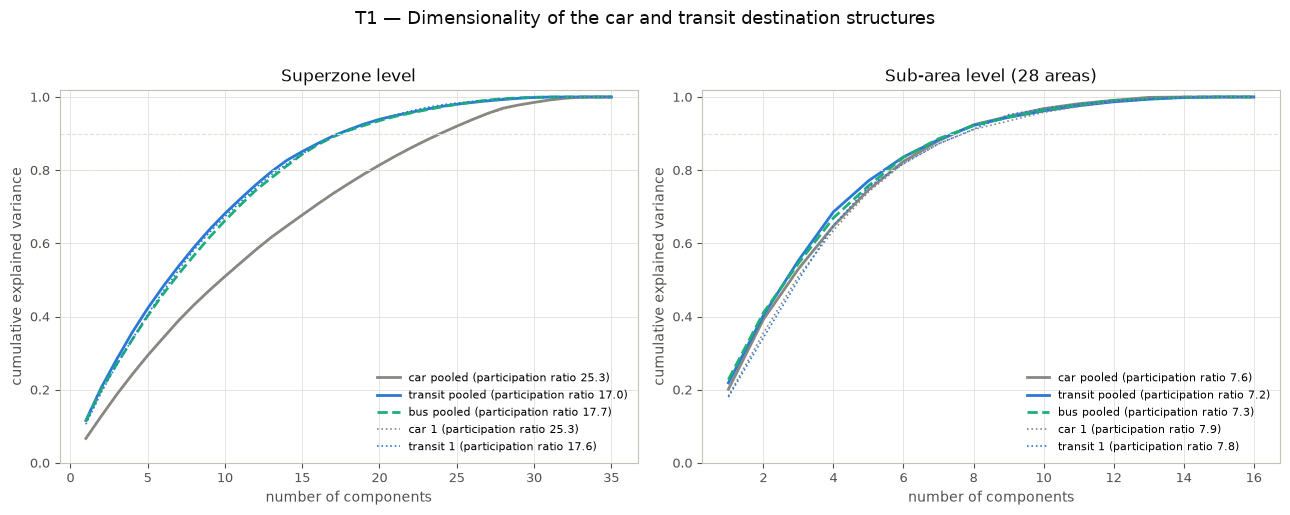

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), facecolor='white')
for ax, (title, PC, pmax) in zip(axes, [('Superzone level', PC_SZ, 36), ('Sub-area level (28 areas)', PC_AREA, 28)]):
    for key, color, ls in [(('car', 'pooled'), MUTED, '-'), (('transit', 'pooled'), BLUE, '-'), (('bus', 'pooled'), AQUA, '--'), (('car', 1), MUTED, ':'), (('transit', 1), BLUE, ':')]:
        cum = np.cumsum(PC[key]['evr'])[:pmax]
        ax.plot(range(1, len(cum) + 1), cum, color=color, linewidth=2 if key[1] == 'pooled' else 1.2, linestyle=ls, label=f"{key[0]} {key[1]} (participation ratio {part_ratio(PC[key]['lam']):.1f})")
    for thr in (0.8, 0.9): ax.axhline(thr, color=GRID, linewidth=0.8, linestyle='--')
    ax.set_ylim(0, 1.02); style_ax(ax, title, 'number of components', 'cumulative explained variance'); ax.legend(frameon=False, loc='lower right', fontsize=8)
fig.suptitle('T1 — Dimensionality of the car and transit destination structures', color=INK, fontsize=13, y=1.02)
plt.tight_layout(); save_show(fig, 'pca_cvt_scree.png')

## 3. T2 — Subspace overlap: car vs transit against each mode's own repeatability and a permuted-geography null

In [6]:
def overlap_table(PC, P, ks, khead, lvl):
    rows = []
    for k in ks:
        rows.append({'level': lvl, 'k': k,
                     'car vs transit (pooled)': mean_cos2(PC[('car', 'pooled')]['V'], PC[('transit', 'pooled')]['V'], k),
                     'car vs bus (pooled)': mean_cos2(PC[('car', 'pooled')]['V'], PC[('bus', 'pooled')]['V'], k),
                     'car d1 vs car d2': mean_cos2(PC[('car', 1)]['V'], PC[('car', 2)]['V'], k),
                     'transit d1 vs transit d2': mean_cos2(PC[('transit', 1)]['V'], PC[('transit', 2)]['V'], k),
                     'car d1 vs transit d2 (cross-day, cross-mode)': mean_cos2(PC[('car', 1)]['V'], PC[('transit', 2)]['V'], k),
                     'chance k/p': k / P[('car', 'pooled')].shape[1]})
    return pd.DataFrame(rows)
ov_sz = overlap_table(PC_SZ, P_SZ, range(1, 17), kSZ, 'SZ'); ov_area = overlap_table(PC_AREA, P_AREA, range(1, 15), kAREA, 'AREA')
ov = pd.concat([ov_sz, ov_area]); ov.to_csv(f'{OUT}/pca_car_vs_transit_overlap.csv', index=False, float_format='%.4f')

def perm_null(Va, Vb, k, n_perm, seed=0):
    r = np.random.default_rng(seed); p = Va.shape[0]
    return np.array([mean_cos2(Va[r.permutation(p)], Vb, k) for _ in range(n_perm)])
perm = {}
for lvl, PC, k in [('SZ', PC_SZ, kSZ), ('AREA', PC_AREA, kAREA)]:
    null = perm_null(PC[('car', 'pooled')]['V'], PC[('transit', 'pooled')]['V'], k, 2000)
    obs = mean_cos2(PC[('car', 'pooled')]['V'], PC[('transit', 'pooled')]['V'], k)
    perm[lvl] = dict(null=null, obs=obs, p=(1 + (null >= obs).sum()) / (1 + len(null)), k=k,
                     car_rep=mean_cos2(PC[('car', 1)]['V'], PC[('car', 2)]['V'], k), tr_rep=mean_cos2(PC[('transit', 1)]['V'], PC[('transit', 2)]['V'], k))
    print(f"{lvl} (k = {k}): car vs transit {obs:.3f} | car day-to-day {perm[lvl]['car_rep']:.3f} | transit day-to-day {perm[lvl]['tr_rep']:.3f} | null mean {null.mean():.3f}, max {null.max():.3f}, p = {perm[lvl]['p']:.4f}")

# household bootstrap of the pooled car-vs-transit overlap (SZ)
def profiles_from_mult(grp, mult_by_hh, level_Z, level_D, ok):
    sub = tm[tm['mainmode'].isin(GROUP[grp])]; w = sub['new_wf'].values * mult_by_hh.reindex(sub['HHID3'].values).fillna(0).values
    return rownorm(counts(sub, level_Z, level_D, w))[ok]
hh_ids = tm['HHID3'].unique(); boot = []
for b in range(200):
    mult = pd.Series(np.bincount(rng.integers(0, len(hh_ids), len(hh_ids)), minlength=len(hh_ids)), index=hh_ids)
    Pc = profiles_from_mult('car', mult, Z_SZ, D_SZ, ok_sz); Pt = profiles_from_mult('transit', mult, Z_SZ, D_SZ, ok_sz)
    good = (Pc.sum(axis=1) > 0) & (Pt.sum(axis=1) > 0)
    boot.append(mean_cos2(pca(Pc[good])['V'], pca(Pt[good])['V'], kSZ))
boot = np.array(boot); print(f"SZ household bootstrap of car-vs-transit overlap (k = {kSZ}): median {np.median(boot):.3f}, 5–95 % {np.percentile(boot, 5):.3f}–{np.percentile(boot, 95):.3f}")

# restricted run: origins with >= 20 sampled transit trips
P_SZr, ok_r = level_profiles('SZ', min_n_transit=20); PC_SZr = {k_: pca(v) for k_, v in P_SZr.items()}
kr = min(kSZ, ok_r.sum() - 2)
print(f"restricted to {ok_r.sum()} origins with >= 20 sampled transit trips (k = {kr}): car vs transit {mean_cos2(PC_SZr[('car', 'pooled')]['V'], PC_SZr[('transit', 'pooled')]['V'], kr):.3f}, "
      f"car day-to-day {mean_cos2(PC_SZr[('car', 1)]['V'], PC_SZr[('car', 2)]['V'], kr):.3f}, transit day-to-day {mean_cos2(PC_SZr[('transit', 1)]['V'], PC_SZr[('transit', 2)]['V'], kr):.3f}")
ov.round(3)

SZ (k = 20): car vs transit 0.749 | car day-to-day 0.951 | transit day-to-day 0.813 | null mean 0.572, max 0.697, p = 0.0005


AREA (k = 6): car vs transit 0.576 | car day-to-day 0.930 | transit day-to-day 0.598 | null mean 0.225, max 0.531, p = 0.0005


SZ household bootstrap of car-vs-transit overlap (k = 20): median 0.709, 5–95 % 0.659–0.764
restricted to 26 origins with >= 20 sampled transit trips (k = 20): car vs transit 0.834, car day-to-day 0.980, transit day-to-day 0.856


,level,k,car vs transit (pooled),car vs bus (pooled),car d1 vs car d2,transit d1 vs transit d2,"car d1 vs transit d2 (cross-day, cross-mode)",chance k/p
0,SZ,1,0.519,0.530,0.953,0.950,0.475,0.028
1,SZ,2,0.583,0.529,0.961,0.855,0.490,0.056
2,SZ,3,0.516,0.477,0.938,0.621,0.354,0.083
3,SZ,4,0.441,0.433,0.960,0.507,0.293,0.111
4,SZ,5,0.503,0.469,0.984,0.712,0.461,0.139
5,SZ,6,0.442,0.510,0.837,0.755,0.458,0.167
6,SZ,7,0.506,0.538,0.978,0.697,0.504,0.194
7,SZ,8,0.595,0.561,0.970,0.718,0.567,0.222
8,SZ,9,0.616,0.601,0.915,0.764,0.550,0.250
9,SZ,10,0.616,0.603,0.883,0.748,0.507,0.278


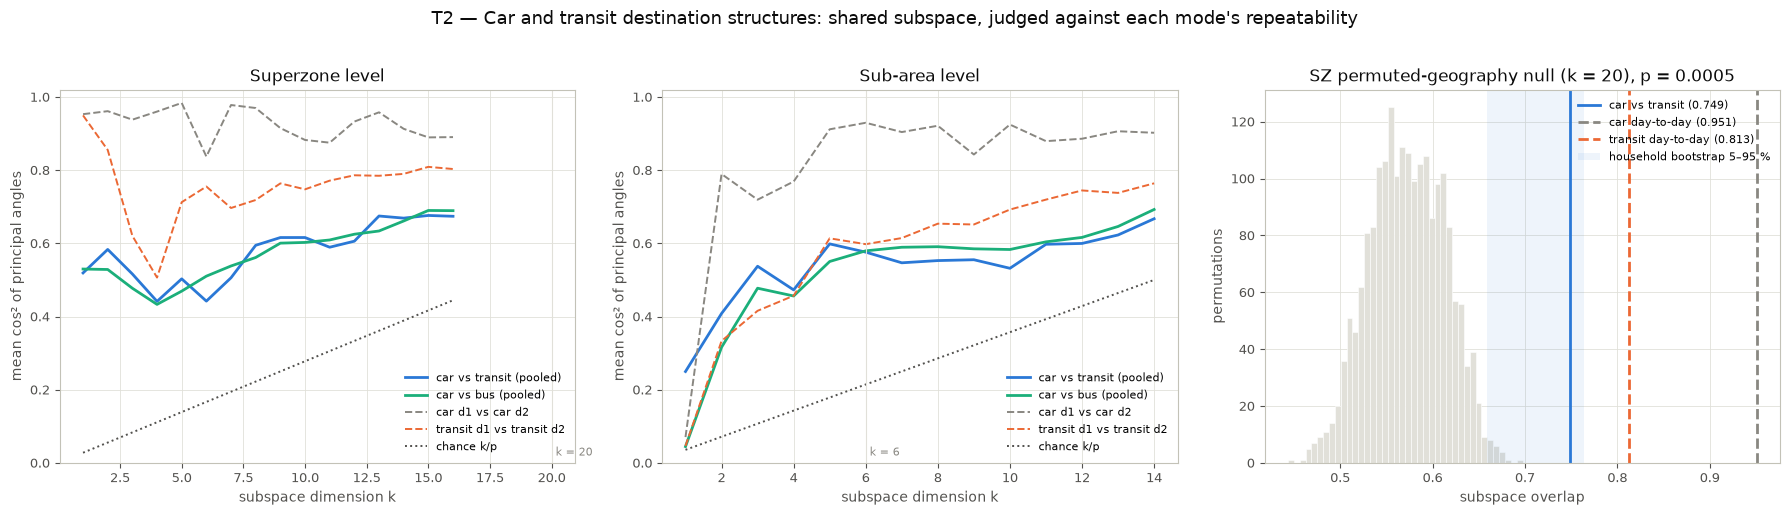

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), facecolor='white')
for ax, (title, o, khead, p) in zip(axes[:2], [('Superzone level', ov_sz, kSZ, ok_sz.sum()), ('Sub-area level', ov_area, kAREA, ok_area.sum())]):
    for col, color, ls in [('car vs transit (pooled)', BLUE, '-'), ('car vs bus (pooled)', AQUA, '-'), ('car d1 vs car d2', MUTED, '--'), ('transit d1 vs transit d2', ORANGE, '--'), ('chance k/p', INK2, ':')]:
        ax.plot(o['k'], o[col], color=color, linewidth=2 if ls == '-' else 1.4, linestyle=ls, label=col)
    ax.axvline(khead, color=GRID, linewidth=0.8); ax.text(khead, 0.02, f' k = {khead}', color=MUTED, fontsize=8); ax.set_ylim(0, 1.02)
    style_ax(ax, title, 'subspace dimension k', 'mean cos² of principal angles'); ax.legend(frameon=False, fontsize=8, loc='lower right')
ax = axes[2]; dd = perm['SZ']
ax.hist(dd['null'], bins=40, color=GRID, edgecolor='white', linewidth=0.4)
ax.axvline(dd['obs'], color=BLUE, linewidth=2, label=f"car vs transit ({dd['obs']:.3f})")
ax.axvline(dd['car_rep'], color=MUTED, linewidth=2, linestyle='--', label=f"car day-to-day ({dd['car_rep']:.3f})")
ax.axvline(dd['tr_rep'], color=ORANGE, linewidth=2, linestyle='--', label=f"transit day-to-day ({dd['tr_rep']:.3f})")
ax.axvspan(np.percentile(boot, 5), np.percentile(boot, 95), color=BLUE, alpha=0.08, lw=0, label='household bootstrap 5–95 %')
style_ax(ax, f"SZ permuted-geography null (k = {dd['k']}), p = {dd['p']:.4f}", 'subspace overlap', 'permutations'); ax.legend(frameon=False, fontsize=8)
fig.suptitle('T2 — Car and transit destination structures: shared subspace, judged against each mode\'s repeatability', color=INK, fontsize=13, y=1.02)
plt.tight_layout(); save_show(fig, 'pca_cvt_subspace_overlap.png')

## 4. T3 — Cross-projection (RCEV)

In [8]:
rows = []
for lvl, P, PC, k in [('SZ', P_SZ, PC_SZ, kSZ), ('AREA', P_AREA, PC_AREA, kAREA)]:
    rows.append({'level': lvl, 'k': k,
                 'transit | car PCs': rcev(P[('transit', 'pooled')], PC[('transit', 'pooled')], PC[('car', 'pooled')], k),
                 'car | transit PCs': rcev(P[('car', 'pooled')], PC[('car', 'pooled')], PC[('transit', 'pooled')], k),
                 'transit d2 | transit d1 PCs (repeatability)': rcev(P[('transit', 2)], PC[('transit', 2)], PC[('transit', 1)], k),
                 'car d2 | car d1 PCs (repeatability)': rcev(P[('car', 2)], PC[('car', 2)], PC[('car', 1)], k)})
t3 = pd.DataFrame(rows); t3.to_csv(f'{OUT}/pca_car_vs_transit_rcev.csv', index=False, float_format='%.4f'); t3.round(3)

,level,k,transit | car PCs,car | transit PCs,transit d2 | transit d1 PCs (repeatability),car d2 | car d1 PCs (repeatability)
0,SZ,20,0.860,0.855,0.889,0.989
1,AREA,6,0.641,0.673,0.706,0.963


## 5. T4 — Component matching and what the leading components mean

car PC2 <-> transit PC2: |congruence| = 0.790  (car variance share 0.06, transit 0.09)
car PC1 <-> transit PC1: |congruence| = 0.720  (car variance share 0.07, transit 0.12)
car PC3 <-> transit PC3: |congruence| = 0.538  (car variance share 0.06, transit 0.08)
car PC5 <-> transit PC4: |congruence| = 0.454  (car variance share 0.05, transit 0.07)
car PC6 <-> transit PC5: |congruence| = 0.218  (car variance share 0.05, transit 0.07)
car PC4 <-> transit PC6: |congruence| = 0.162  (car variance share 0.05, transit 0.06)
car PC1 (share 0.07): corr(score, self-containment) +0.23; corr(score, share to Haifa SZs) -0.14
car PC2 (share 0.06): corr(score, self-containment) -0.74; corr(score, share to Haifa SZs) +0.65
car PC3 (share 0.06): corr(score, self-containment) -0.12; corr(score, share to Haifa SZs) +0.14
transit PC1 (share 0.12): corr(score, self-containment) -0.06; corr(score, share to Haifa SZs) -0.38
transit PC2 (share 0.09): corr(score, self-containment) +0.77; corr(score, share to Ha

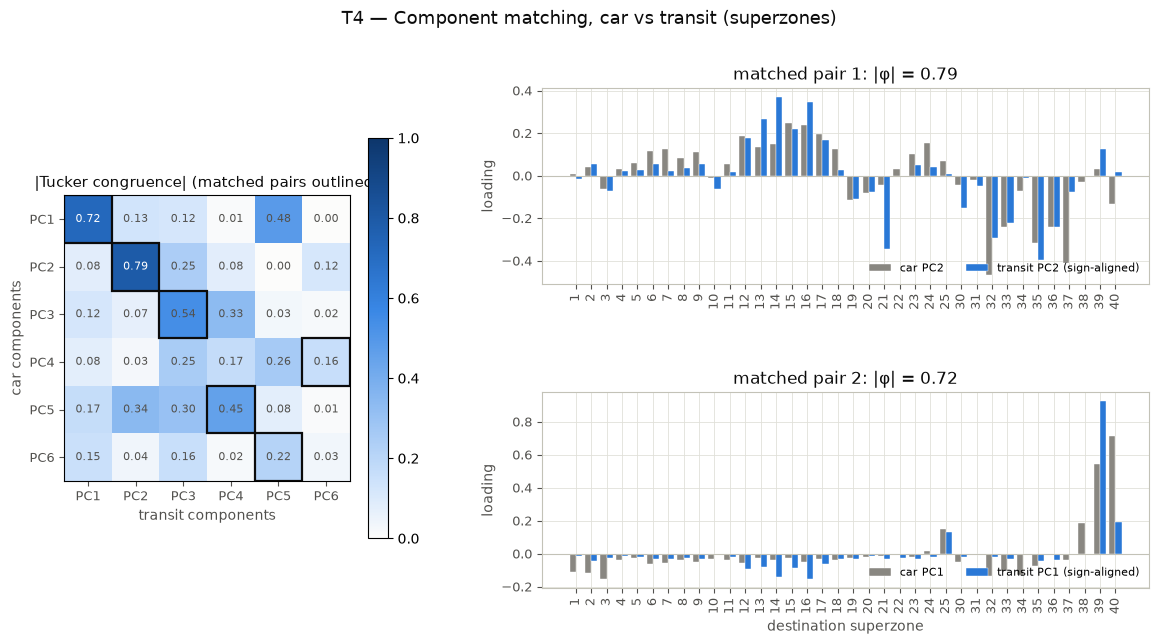

In [9]:
kc = 6
Vc, Vt = PC_SZ[('car', 'pooled')]['V'][:, :kc], PC_SZ[('transit', 'pooled')]['V'][:, :kc]
C = Vc.T @ Vt; ri, ci = linear_sum_assignment(-np.abs(C)); match = sorted(zip(ri, ci), key=lambda x: -abs(C[x[0], x[1]]))
for i, j in match: print(f"car PC{i+1} <-> transit PC{j+1}: |congruence| = {abs(C[i, j]):.3f}  (car variance share {PC_SZ[('car','pooled')]['evr'][i]:.2f}, transit {PC_SZ[('transit','pooled')]['evr'][j]:.2f})")
sz_ids = np.array(SZ)[ok_sz]
# interpretation: correlation of component scores with self-containment and with the share of trips to the Haifa superzones
HAIFA = [12, 13, 14, 15, 16, 17, 18]; hcols = [i for i, z in enumerate(SZ) if z in HAIFA]
for key in [('car', 'pooled'), ('transit', 'pooled')]:
    P, pc = P_SZ[key], PC_SZ[key]; selfc = np.diag(P) if P.shape[0] == P.shape[1] else np.array([P[i, np.where(np.array(SZ) == z)[0][0]] for i, z in enumerate(sz_ids)])
    haifa = P[:, hcols].sum(axis=1)
    for j in range(3):
        print(f"{key[0]} PC{j+1} (share {pc['evr'][j]:.2f}): corr(score, self-containment) {np.corrcoef(pc['scores'][:, j], selfc)[0,1]:+.2f}; corr(score, share to Haifa SZs) {np.corrcoef(pc['scores'][:, j], haifa)[0,1]:+.2f}")

fig = plt.figure(figsize=(14, 6.5), facecolor='white'); gs = fig.add_gridspec(2, 2, width_ratios=[1, 1.7], hspace=0.55, wspace=0.25)
ax = fig.add_subplot(gs[:, 0]); im = ax.imshow(np.abs(C), cmap=CMAP_SEQ, vmin=0, vmax=1)
for i in range(kc):
    for j in range(kc):
        v = abs(C[i, j]); ax.text(j, i, f'{v:.2f}', ha='center', va='center', fontsize=8, color='white' if v > 0.55 else INK2)
for i, j in zip(ri, ci): ax.add_patch(plt.Rectangle((j - .5, i - .5), 1, 1, fill=False, edgecolor=INK, linewidth=1.6))
ax.set_xticks(range(kc), [f'PC{j+1}' for j in range(kc)]); ax.set_yticks(range(kc), [f'PC{i+1}' for i in range(kc)])
ax.set_xlabel('transit components', color=INK2); ax.set_ylabel('car components', color=INK2); ax.set_title('|Tucker congruence| (matched pairs outlined)', color=INK, fontsize=11); ax.tick_params(colors=INK2, labelsize=9); fig.colorbar(im, ax=ax, shrink=0.8)
x = np.arange(len(SZ))
for row, (i, j) in enumerate(match[:2]):
    ax = fig.add_subplot(gs[row, 1]); sgn = np.sign(C[i, j])
    ax.bar(x - 0.2, Vc[:, i], width=0.4, color=MUTED, edgecolor='white', linewidth=0.3, label=f'car PC{i+1}')
    ax.bar(x + 0.2, sgn * Vt[:, j], width=0.4, color=BLUE, edgecolor='white', linewidth=0.3, label=f'transit PC{j+1} (sign-aligned)')
    ax.set_xticks(x, SZ, fontsize=6.5, rotation=90); style_ax(ax, f'matched pair {row+1}: |φ| = {abs(C[i, j]):.2f}', 'destination superzone' if row == 1 else None, 'loading'); ax.axhline(0, color=AXIS, linewidth=0.8); ax.legend(frameon=False, fontsize=8, loc='lower right', ncols=2)
fig.suptitle('T4 — Component matching, car vs transit (superzones)', color=INK, fontsize=13, y=1.0)
save_show(fig, 'pca_cvt_component_match.png')

## 6. T5 / T6 — Where car and transit diverge: joint map, common direction, diagonal, and the difference matrix

In [10]:
Pc, Pt = P_SZ[('car', 'pooled')], P_SZ[('transit', 'pooled')]; Pc1, Pc2, Pt1, Pt2 = P_SZ[('car', 1)], P_SZ[('car', 2)], P_SZ[('transit', 1)], P_SZ[('transit', 2)]
n = Pc.shape[0]; pcJ = pca(np.vstack([Pc, Pt])); sc_c, sc_t = pcJ['scores'][:n], pcJ['scores'][n:]
disp = np.linalg.norm(Pt - Pc, axis=1); disp_car = np.linalg.norm(Pc1 - Pc2, axis=1); disp_tr = np.linalg.norm(Pt1 - Pt2, axis=1)
Dm = Pt - Pc; obs_shift = np.linalg.norm(Dm.mean(axis=0)); flips = rng.choice([-1., 1.], size=(10000, n))
null_shift = np.linalg.norm((flips[:, :, None] * Dm[None]).mean(axis=1), axis=1); p_shift = (1 + (null_shift >= obs_shift).sum()) / 10001
diag_c = np.array([Pc[i, sz_pos[z]] for i, z in enumerate(sz_ids)]); diag_t = np.array([Pt[i, sz_pos[z]] for i, z in enumerate(sz_ids)])
D_sq = (Dm ** 2).sum(); diag_share = sum(Dm[i, sz_pos[z]] ** 2 for i, z in enumerate(sz_ids)) / D_sq
haifa_c, haifa_t = Pc[:, hcols].sum(axis=1), Pt[:, hcols].sum(axis=1)
print(f"mean profile distance: transit vs car {disp.mean():.3f}; car day-to-day {disp_car.mean():.3f}; transit day-to-day {disp_tr.mean():.3f}")
print(f"mean self-containment: car {diag_c.mean():.3f}, transit {diag_t.mean():.3f}; diagonal share of squared divergence {diag_share:.3f}")
print(f"common-direction test: |mean difference| {obs_shift:.4f}, sign-flip P(null >= obs) = {p_shift:.4f}  -> {'a common shift direction exists' if p_shift < 0.05 else 'no common direction: zone-specific'}")
mean_shift = pd.Series(Dm.mean(axis=0), index=SZ).sort_values()
print("destinations gaining the most transit share relative to car (mean over origins):"); print(mean_shift.tail(6).round(3).to_string())
print("destinations losing:"); print(mean_shift.head(4).round(3).to_string())
by_origin = pd.DataFrame({'origin SZ': sz_ids, 'localities': [sz_loc.get(z, '') for z in sz_ids], 'sampled transit trips (2 days)': SETS[('transit', 'pooled')]['n_sz'][ok_sz].round(0),
                          'car self-containment': diag_c, 'transit self-containment': diag_t, 'car share to Haifa SZs': haifa_c, 'transit share to Haifa SZs': haifa_t,
                          'transit − car displacement': disp, 'car day-to-day': disp_car, 'transit day-to-day': disp_tr})
by_origin.to_csv(f'{OUT}/pca_car_vs_transit_by_origin.csv', index=False, float_format='%.4f')
print(by_origin.sort_values('transit − car displacement', ascending=False).head(10).round(2).to_string(index=False))

mean profile distance: transit vs car 0.327; car day-to-day 0.058; transit day-to-day 0.215
mean self-containment: car 0.621, transit 0.453; diagonal share of squared divergence 0.439
common-direction test: |mean difference| 0.0760, sign-flip P(null >= obs) = 0.0426  -> a common shift direction exists
destinations gaining the most transit share relative to car (mean over origins):
21    0.008
39    0.012
12    0.020
13    0.027
14    0.031
16    0.033
destinations losing:
24   -0.018
38   -0.018
37   -0.018
34   -0.016
 origin SZ                              localities  sampled transit trips (2 days)  car self-containment  transit self-containment  car share to Haifa SZs  transit share to Haifa SZs  transit − car displacement  car day-to-day  transit day-to-day
        38                      אום אל פאחם, ערערה                             2.0                  0.57                      0.00                    0.02                        0.00                        1.02            0.07  

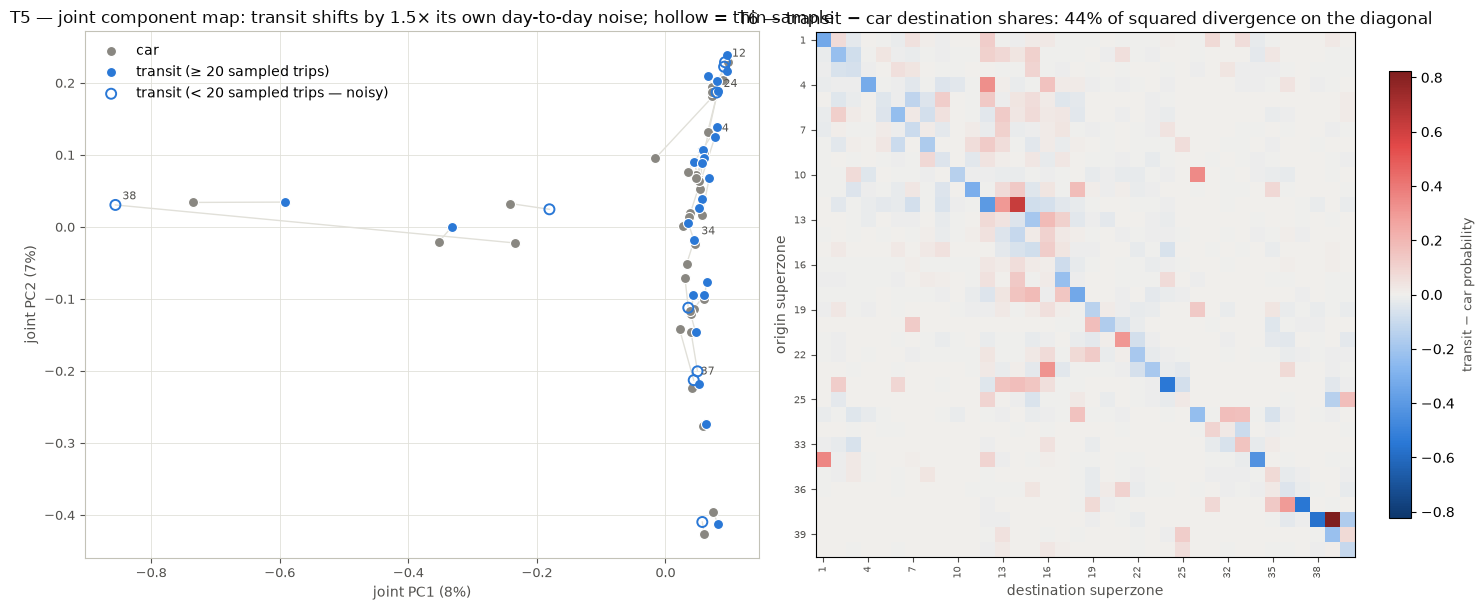

diagonal removed (35 rows, k = 20): car vs transit 0.716 (with diagonal 0.749); car day-to-day 0.865; transit day-to-day 0.787


,0,1
level,SZ,AREA
k,20,6
car vs transit overlap,0.749,0.576
bootstrap p5,0.659,NaN
bootstrap p95,0.764,NaN
car day-to-day,0.951,0.93
transit day-to-day,0.813,0.598
permutation null mean,0.572,0.225
permutation p,0.0,0.0
overlap without diagonal,0.716,NaN


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6.2), facecolor='white')
ax = axes[0]
for i in range(n): ax.plot([sc_c[i, 0], sc_t[i, 0]], [sc_c[i, 1], sc_t[i, 1]], color=GRID, linewidth=1.0, zorder=1)
thin = SETS[('transit', 'pooled')]['n_sz'][ok_sz] < 20
ax.scatter(sc_c[:, 0], sc_c[:, 1], s=52, color=MUTED, edgecolors='white', linewidths=0.8, zorder=2, label='car')
ax.scatter(sc_t[~thin, 0], sc_t[~thin, 1], s=52, color=BLUE, edgecolors='white', linewidths=0.8, zorder=2, label='transit (≥ 20 sampled trips)')
ax.scatter(sc_t[thin, 0], sc_t[thin, 1], s=52, facecolors='none', edgecolors=BLUE, linewidths=1.4, zorder=2, label='transit (< 20 sampled trips — noisy)')
for i in np.argsort(-disp)[:6]: ax.annotate(str(sz_ids[i]), (sc_t[i, 0], sc_t[i, 1]), textcoords='offset points', xytext=(5, 4), fontsize=8, color=INK2)
style_ax(ax, f'T5 — joint component map: transit shifts by {disp.mean() / disp_tr.mean():.1f}× its own day-to-day noise; hollow = thin sample', f"joint PC1 ({pcJ['evr'][0]:.0%})", f"joint PC2 ({pcJ['evr'][1]:.0%})"); ax.legend(frameon=False, fontsize=10)
ax = axes[1]; vmax = np.abs(Dm).max(); im = ax.imshow(Dm, cmap=CMAP_DIV, vmin=-vmax, vmax=vmax)
ax.set_xticks(range(0, len(SZ), 3), np.array(SZ)[::3], fontsize=7, rotation=90); ax.set_yticks(range(0, n, 3), sz_ids[::3], fontsize=7)
ax.set_xlabel('destination superzone', color=INK2); ax.set_ylabel('origin superzone', color=INK2); ax.tick_params(colors=INK2)
ax.set_title(f'T6 — transit − car destination shares: {diag_share:.0%} of squared divergence on the diagonal', color=INK, fontsize=12)
cb = fig.colorbar(im, ax=ax, shrink=0.85); cb.set_label('transit − car probability', color=INK2, fontsize=9)
plt.tight_layout(); save_show(fig, 'pca_cvt_divergence.png')

# diagonal ablation
def strip_diag_rows(P, ids):
    A = P.copy()
    for i, z in enumerate(ids): A[i, sz_pos[z]] = 0
    rs = A.sum(axis=1, keepdims=True); ok = rs[:, 0] > 0
    return np.divide(A, rs, out=np.zeros_like(A), where=rs > 0), ok
abl = {k_: strip_diag_rows(P_SZ[k_], sz_ids) for k_ in [('car', 'pooled'), ('transit', 'pooled'), ('car', 1), ('car', 2), ('transit', 1), ('transit', 2)]}
okx = np.logical_and.reduce([v[1] for v in abl.values()]); PCx = {k_: pca(v[0][okx]) for k_, v in abl.items()}
print(f"diagonal removed ({okx.sum()} rows, k = {kSZ}): car vs transit {mean_cos2(PCx[('car','pooled')]['V'], PCx[('transit','pooled')]['V'], kSZ):.3f} "
      f"(with diagonal {perm['SZ']['obs']:.3f}); car day-to-day {mean_cos2(PCx[('car',1)]['V'], PCx[('car',2)]['V'], kSZ):.3f}; transit day-to-day {mean_cos2(PCx[('transit',1)]['V'], PCx[('transit',2)]['V'], kSZ):.3f}")
summary = pd.DataFrame([{'level': 'SZ', 'k': kSZ, 'car vs transit overlap': perm['SZ']['obs'], 'bootstrap p5': np.percentile(boot, 5), 'bootstrap p95': np.percentile(boot, 95), 'car day-to-day': perm['SZ']['car_rep'], 'transit day-to-day': perm['SZ']['tr_rep'], 'permutation null mean': perm['SZ']['null'].mean(), 'permutation p': perm['SZ']['p'],
                         'overlap without diagonal': mean_cos2(PCx[('car','pooled')]['V'], PCx[('transit','pooled')]['V'], kSZ), 'mean self-containment car': diag_c.mean(), 'mean self-containment transit': diag_t.mean(), 'diagonal share of divergence': diag_share, 'common-direction p': p_shift, 'displacement ratio (vs transit day-to-day)': disp.mean() / disp_tr.mean()},
                        {'level': 'AREA', 'k': kAREA, 'car vs transit overlap': perm['AREA']['obs'], 'car day-to-day': perm['AREA']['car_rep'], 'transit day-to-day': perm['AREA']['tr_rep'], 'permutation null mean': perm['AREA']['null'].mean(), 'permutation p': perm['AREA']['p']}])
summary.to_csv(f'{OUT}/pca_car_vs_transit_summary.csv', index=False, float_format='%.4f'); summary.round(3).T

## 7. The same tests at other resolutions — corridor aggregation areas and TAZ level

Three further levels, each with the same statistics and the same references. Because transit is thin, each level is run on the origins with at least a minimum number of sampled transit trips (both days pooled), and the day-to-day references are computed on the origins that have trips on both days. The permutation null uses 500 permutations per level.

| Level | Origins × destinations | Note |
|---|---|---|
| Corridor aggregation areas | 28 × 28 sub-areas (`Input/Submatrix_tazs.xlsx`), origins restricted to the 18 line areas as a variant | the reporting geography of the corridor profiles |
| TAZ × superzone | 778 TAZ origins × 36 superzone destinations | keeps TAZ origins while destinations stay estimable |
| TAZ × TAZ | 778 × 778 | the base's resolution; transit has ≈ 2.5 sampled trips per origin on average |

In [12]:
M_taz = np.eye(N)
Z_TAZ, D_TAZ = S_o @ M_taz, S_d @ M_taz
def build_sets(Zo, Zd):
    out = {}
    for grp, codes in GROUP.items():
        sub = tm[tm['mainmode'].isin(codes)]
        for day in (1, 2, 'pooled'):
            s_ = sub if day == 'pooled' else sub[sub['SurveyDay'] == day]
            out[(grp, day)] = {'M': counts(s_, Zo, Zd), 'n': n_by_origin(s_, Zo)}
    return out
def run_level(label, sets, min_n, origin_mask=None, n_perm=500, k_cap=None, diag_ids=None):
    ok = (sets[('car', 'pooled')]['M'].sum(axis=1) > 0) & (sets[('transit', 'pooled')]['n'] >= min_n)
    if origin_mask is not None: ok &= origin_mask
    Pc, Pt = rownorm(sets[('car', 'pooled')]['M'])[ok], rownorm(sets[('transit', 'pooled')]['M'])[ok]
    pc_c, pc_t = pca(Pc), pca(Pt)
    k = n_comp(pc_c['evr'], .8); k = min(k, ok.sum() - 2, Pc.shape[1] - 1) if k_cap is None else min(k, k_cap, ok.sum() - 2)
    obs = mean_cos2(pc_c['V'], pc_t['V'], k)
    null = perm_null(pc_c['V'], pc_t['V'], k, n_perm, seed=1)
    # repeatability on origins with trips on both days (same min_n on the pooled transit count)
    def rep(grp):
        okd = ok & (sets[(grp, 1)]['M'].sum(axis=1) > 0) & (sets[(grp, 2)]['M'].sum(axis=1) > 0)
        P1, P2 = rownorm(sets[(grp, 1)]['M'])[okd], rownorm(sets[(grp, 2)]['M'])[okd]
        kk = min(k, okd.sum() - 2); return mean_cos2(pca(P1)['V'], pca(P2)['V'], kk), int(okd.sum())
    car_rep, n_car = rep('car'); tr_rep, n_tr = rep('transit')
    r_tc = rcev(Pt, pc_t, pc_c, k)
    Dm = Pt - Pc; disp = np.linalg.norm(Dm, axis=1)
    flips = rng.choice([-1., 1.], size=(5000, ok.sum())); null_shift = np.linalg.norm((flips[:, :, None] * Dm[None]).mean(axis=1), axis=1)
    p_shift = (1 + (null_shift >= np.linalg.norm(Dm.mean(axis=0))).sum()) / 5001
    res = {'level': label, 'min sampled transit trips': min_n, 'origins used': int(ok.sum()), 'destinations (features)': Pc.shape[1], 'k': k,
           'car vs transit overlap': obs, 'car day-to-day': car_rep, 'transit day-to-day': tr_rep, 'origins in day-to-day (car / transit)': f'{n_car} / {n_tr}',
           'null mean': null.mean(), 'null max': null.max(), 'permutation p': (1 + (null >= obs).sum()) / (1 + len(null)),
           'transit variance captured by car PCs': r_tc, 'mean displacement': disp.mean(), 'common-direction p': p_shift}
    if diag_ids is not None:
        ids = np.array(diag_ids)[ok]; pos = {z: i for i, z in enumerate(diag_ids)}
        dc = np.array([Pc[i, pos[z]] for i, z in enumerate(ids)]); dt = np.array([Pt[i, pos[z]] for i, z in enumerate(ids)])
        res.update({'self-containment car': dc.mean(), 'self-containment transit': dt.mean(), 'diagonal share of divergence': sum(Dm[i, pos[z]] ** 2 for i, z in enumerate(ids)) / (Dm ** 2).sum()})
    return res, ok, Pc, Pt, Dm

sets_area = build_sets(Z_AREA, D_AREA); sets_tz = build_sets(Z_TAZ, D_SZ); sets_tt = build_sets(Z_TAZ, D_TAZ)
ref = pd.read_csv('Output/ths2017/three_mode_2022/corridor_link_flows_transit_2022.csv'); LINE = list(ref['from_code']) + [int(ref['to_code'].iloc[-1])]
line_mask = np.array([a in LINE for a in AREA])
results = []
res_sz = {'level': 'superzone × superzone', 'min sampled transit trips': 1, 'origins used': int(ok_sz.sum()), 'destinations (features)': len(SZ), 'k': kSZ, 'car vs transit overlap': perm['SZ']['obs'], 'car day-to-day': perm['SZ']['car_rep'], 'transit day-to-day': perm['SZ']['tr_rep'], 'null mean': perm['SZ']['null'].mean(), 'null max': perm['SZ']['null'].max(), 'permutation p': perm['SZ']['p'], 'transit variance captured by car PCs': t3.loc[0, 'transit | car PCs'], 'mean displacement': disp.mean(), 'common-direction p': p_shift, 'self-containment car': diag_c.mean(), 'self-containment transit': diag_t.mean(), 'diagonal share of divergence': diag_share}
results.append(res_sz)
for min_n in (1, 10, 20):
    r, *_ = run_level('corridor areas × areas (28)', sets_area, min_n, diag_ids=AREA); results.append(r)
r_line, ok_line, Pc_line, Pt_line, Dm_line = run_level('line areas × areas (18 origins)', sets_area, 10, origin_mask=line_mask, diag_ids=AREA); results.append(r_line)
for min_n in (5, 10, 20):
    r, *_ = run_level('TAZ × superzone', sets_tz, min_n, k_cap=20); results.append(r)
for min_n in (5, 10, 20):
    r, ok_tt, Pc_tt, Pt_tt, Dm_tt = run_level('TAZ × TAZ', sets_tt, min_n, k_cap=40, diag_ids=list(TAZ)); results.append(r)
levels = pd.DataFrame(results); levels.to_csv(f'{OUT}/pca_car_vs_transit_levels.csv', index=False, float_format='%.4f')
print(levels[['level', 'min sampled transit trips', 'origins used', 'destinations (features)', 'k', 'car vs transit overlap', 'car day-to-day', 'transit day-to-day', 'null mean', 'permutation p', 'transit variance captured by car PCs', 'self-containment car', 'self-containment transit', 'diagonal share of divergence', 'common-direction p']].round(3).to_string(index=False))

                          level  min sampled transit trips  origins used  destinations (features)  k  car vs transit overlap  car day-to-day  transit day-to-day  null mean  permutation p  transit variance captured by car PCs  self-containment car  self-containment transit  diagonal share of divergence  common-direction p
          superzone × superzone                          1            35                       36 20                   0.749           0.951               0.813      0.572          0.000                                 0.860                 0.621                     0.453                         0.439               0.043
    corridor areas × areas (28)                          1            23                       28  8                   0.549           0.723               0.666      0.299          0.012                                 0.500                 0.395                     0.152                         0.252               0.422
    corridor areas × areas (28)

In [13]:
# corridor areas: per-origin displacement and Haifa-line-bound shares (origins with >= 10 sampled transit trips)
r_area, ok_a, Pc_a, Pt_a, Dm_a = run_level('corridor areas × areas (28)', sets_area, 10, diag_ids=AREA)
HAIFA_AREAS = [a for a in LINE if a in (2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12)]      # Matam … Namal, Neve Yosef: the Haifa segment of the line
hcols_a = [apos[a] for a in HAIFA_AREAS]
ids_a = np.array(AREA)[ok_a]
tbl = pd.DataFrame({'origin area': ids_a, 'name': [area_names[a] for a in ids_a], 'on the line': [a in LINE for a in ids_a],
                    'sampled transit trips (2 days)': sets_area[('transit', 'pooled')]['n'][ok_a].round(0),
                    'car self-containment': [Pc_a[i, apos[a]] for i, a in enumerate(ids_a)], 'transit self-containment': [Pt_a[i, apos[a]] for i, a in enumerate(ids_a)],
                    'car share to Haifa line areas': Pc_a[:, hcols_a].sum(axis=1), 'transit share to Haifa line areas': Pt_a[:, hcols_a].sum(axis=1),
                    'transit − car displacement': np.linalg.norm(Dm_a, axis=1)})
tbl.to_csv(f'{OUT}/pca_car_vs_transit_by_area.csv', index=False, float_format='%.4f')
print(tbl.sort_values('transit − car displacement', ascending=False).round(2).to_string(index=False))
mean_shift_a = pd.Series(Dm_a.mean(axis=0), index=AREA).sort_values()
print("\ndestination areas gaining transit share relative to car (mean over origins):"); print(pd.DataFrame({'area': mean_shift_a.tail(6).index, 'name': [area_names[a] for a in mean_shift_a.tail(6).index], 'shift': mean_shift_a.tail(6).values.round(3)}).to_string(index=False))
print("losing:"); print(pd.DataFrame({'area': mean_shift_a.head(5).index, 'name': [area_names[a] for a in mean_shift_a.head(5).index], 'shift': mean_shift_a.head(5).values.round(3)}).to_string(index=False))

 origin area                  name  on the line  sampled transit trips (2 days)  car self-containment  transit self-containment  car share to Haifa line areas  transit share to Haifa line areas  transit − car displacement
          27          Nesher Lower        False                            14.0                  0.51                      0.01                           0.21                               0.71                        0.93
           1           TiratCarmel         True                            11.0                  0.78                      0.14                           0.14                               0.86                        0.77
          17   Kiryat Bialik South         True                            11.0                  0.07                      0.41                           0.22                               0.13                        0.52
          10          Hadar Carmel         True                            24.0                  0.55           


destination areas gaining transit share relative to car (mean over origins):
 area                name  shift
    7      Kiryat Eliezer  0.018
    3          Neot Peres  0.028
   17 Kiryat Bialik South  0.030
    2               Matam  0.041
   15        Kiryat Nahum  0.045
    9          Lower City  0.049
losing:
 area          name  shift
   27  Nesher Lower -0.042
    1   TiratCarmel -0.040
   13     Hamifrats -0.032
    8     Hamoshava -0.022
   23 Nazareth Area -0.020


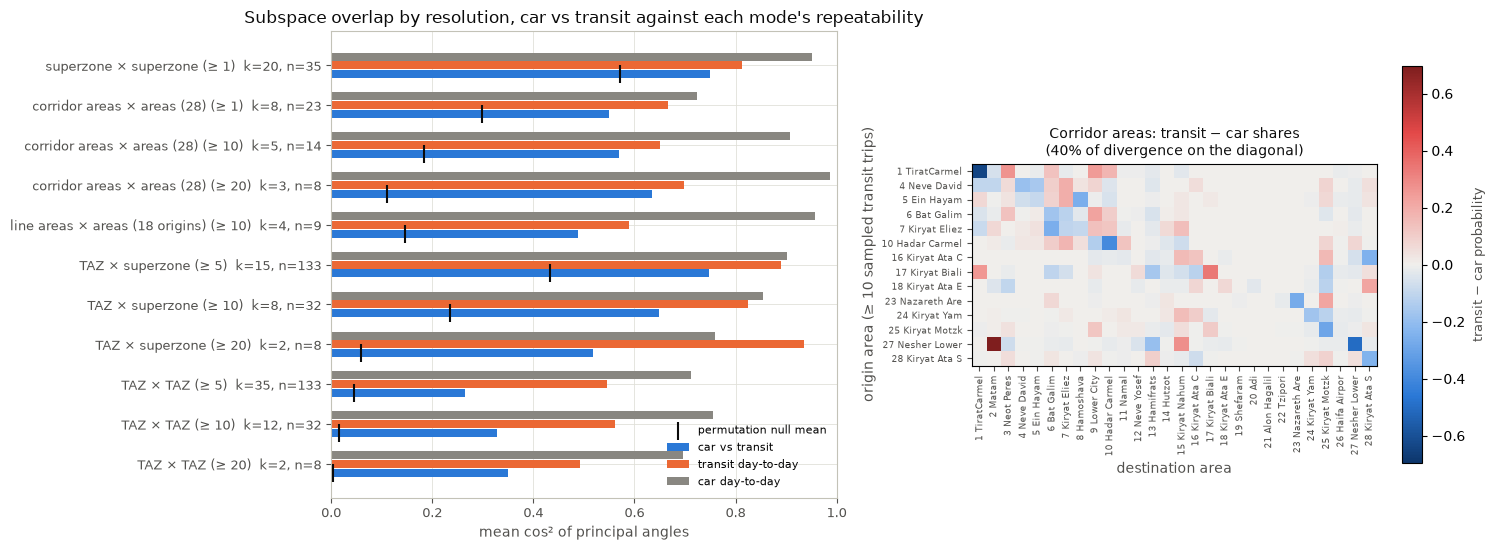

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.6), facecolor='white')
ax = axes[0]
lv = levels.copy(); lv['label'] = lv['level'] + ' (≥ ' + lv['min sampled transit trips'].astype(str) + ')'
y = np.arange(len(lv))
ax.barh(y + 0.22, lv['car vs transit overlap'], height=0.2, color=BLUE, label='car vs transit')
ax.barh(y, lv['transit day-to-day'], height=0.2, color=ORANGE, label='transit day-to-day')
ax.barh(y - 0.22, lv['car day-to-day'], height=0.2, color=MUTED, label='car day-to-day')
ax.scatter(lv['null mean'], y + 0.22, marker='|', s=160, color=INK, label='permutation null mean', zorder=3)
ax.set_yticks(y); ax.set_yticklabels([f"{l}  k={k}, n={n}" for l, k, n in zip(lv['label'], lv['k'], lv['origins used'])], fontsize=8); ax.invert_yaxis(); ax.set_xlim(0, 1)
style_ax(ax, 'Subspace overlap by resolution, car vs transit against each mode\'s repeatability', 'mean cos² of principal angles', None); ax.legend(frameon=False, fontsize=8, loc='lower right')
ax = axes[1]
vmax = np.abs(Dm_a).max(); im = ax.imshow(Dm_a, cmap=CMAP_DIV, vmin=-vmax, vmax=vmax)
ax.set_xticks(range(len(AREA)), [f'{a} {area_names[a][:12]}' for a in AREA], fontsize=6.5, rotation=90); ax.set_yticks(range(len(ids_a)), [f'{a} {area_names[a][:12]}' for a in ids_a], fontsize=6.5)
ax.tick_params(colors=INK2); ax.set_xlabel('destination area', color=INK2); ax.set_ylabel('origin area (≥ 10 sampled transit trips)', color=INK2)
ax.set_title(f"Corridor areas: transit − car shares\n({r_area['diagonal share of divergence']:.0%} of divergence on the diagonal)", color=INK, fontsize=10)
cb = fig.colorbar(im, ax=ax, shrink=0.85); cb.set_label('transit − car probability', color=INK2, fontsize=9)
plt.tight_layout(); save_show(fig, 'pca_cvt_levels.png')

## Findings

(filled in after execution — see METHODOLOGY §6s)

## By resolution — corridor aggregation areas and TAZ level

| Level (origins with ≥ n sampled transit trips) | Origins | k | Car vs transit | Car day-to-day | Transit day-to-day | Null mean | Transit variance captured by car PCs | Common direction |
|---|---|---|---|---|---|---|---|---|
| Superzone × superzone (≥ 1) | 35 | 20 | 0.75 | 0.95 | 0.81 | 0.57 | 0.86 | p = 0.04 |
| Corridor areas × areas (≥ 10) | 14 | 5 | 0.57 | 0.91 | 0.65 | 0.18 | 0.63 | p = 0.62 |
| Corridor areas × areas (≥ 20) | 8 | 3 | 0.64 | 0.99 | 0.70 | 0.11 | 0.83 | p = 0.70 |
| Line areas only (≥ 10) | 9 | 4 | 0.49 | 0.96 | 0.59 | 0.15 | 0.65 | p = 0.56 |
| TAZ × superzone (≥ 5) | 133 | 15 | 0.75 | 0.90 | 0.89 | 0.43 | 0.89 | **p = 0.002** |
| TAZ × superzone (≥ 10) | 32 | 8 | 0.65 | 0.86 | 0.82 | 0.24 | 0.82 | p = 0.70 |
| TAZ × TAZ (≥ 5) | 133 | 35 | 0.27 | 0.71 | 0.55 | 0.05 | 0.39 | **p < 0.001** |
| TAZ × TAZ (≥ 10) | 32 | 12 | 0.33 | 0.76 | 0.56 | 0.02 | 0.48 | p = 0.19 |

All overlaps are far above their nulls (permutation p ≤ 0.012 everywhere). What changes with resolution is the relation to transit's own repeatability:

**5. Corridor aggregation areas: the same picture as the superzones, at transit's noise floor.** With 14 origins (≥ 10 sampled transit trips) the car-vs-transit overlap (0.57) sits just below transit's day-to-day value (0.65) while car repeats at 0.91; with 8 well-sampled origins 0.64 against 0.70. Car and transit are as alike as transit is to itself; nothing finer can be resolved at this level from the survey. Self-containment is lower for both at area size (car 0.42, transit 0.23), the diagonal holds 40 % of the divergence, and no common direction is detectable with so few origins (p = 0.6) — the mean shifts still point the same way as at superzone level (Lower City +0.05, Kiryat Nahum +0.05, Matam +0.04, Neot Peres +0.03 gain transit share; Nesher Lower, Tirat Carmel, Hamifrats, Hamoshava, Nazareth Area lose). Per origin, the well-sampled outer areas show the Haifa pull clearly: Kiryat Motzkin-Bialik (118 sampled transit trips) sends 26 % of its transit trips to the Haifa line areas against 6 % of its car trips; Kiryat Yam (68) 13 % vs 7 %; Kiryat Ata South (46) 12 % vs 3 %; Tirat Carmel (11 trips, thin) 86 % vs 14 %. Origins inside Haifa send 70–95 % of both modes to the Haifa line areas — there the modes do not differ in destination geography.

**6. TAZ origins, superzone destinations: the difference becomes statistically clear.** On the 133 TAZs with at least 5 sampled transit trips, car vs transit is 0.75 while transit repeats at 0.89 and car at 0.90 — a gap that is not sampling noise — and the sign-flip test finds a common direction (p = 0.002). This is the resolution at which the systematic finding of §2 (transit less local, more Haifa-core-bound) is best established: many origins, estimable destination profiles.

**7. TAZ × TAZ: only the coarse structure is shared.** At full resolution car vs transit is 0.27 against a transit repeatability of 0.55, a car repeatability of 0.71 and chance 0.05 (133 origins, k = 35); car components capture only 39 % of transit's variance; self-containment is 0.13 (car) and 0.06 (transit). The two modes share the superzone-level geography but not the fine destination cells — as expected when transit destinations follow stops and trunk routes rather than the employment spread that places car trips. This is also the reason the base keeps transit destinations from the OnBoard pattern below superzone level rather than from a scaled car matrix, and why no TAZ-level statement about transit should be made from the survey alone (2.5 sampled transit trips per origin TAZ on average).

Outputs added: `Output/ths2017/tests/pca_car_vs_transit_levels.csv`, `pca_car_vs_transit_by_area.csv`; figure `pca_cvt_levels.png`.